# 1. Load và kiểm tra dữ liệu:

In [1]:
import re
import statistics as stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

!pip install nltk
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from torch.optim import AdamW

In [2]:
# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
# Liên kết drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrmorj/hate-speech-and-offensive-language-dataset")

print("Path to dataset files:", path)
print("Files in dataset directory:", os.listdir(path))

100%|██████████| 1.01M/1.01M [00:00<00:00, 67.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mrmorj/hate-speech-and-offensive-language-dataset/versions/1
Files in dataset directory: ['labeled_data.csv']


In [5]:
# Đọc và kiểm tra dữ liệu:
from IPython.display import display
data = pd.read_csv(path + '/labeled_data.csv')
print("dataset head:")
display(data.head())
print("dataset info:")
data.info()

dataset head:


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [6]:
# Làm sạch dữ liệu và chuẩn hóa nhãn:
data_cleaned = data.drop(columns = ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither'])
data_cleaned.rename(columns = {'class':'label'}, inplace=True)

label_mapping = {0: 'hate_speech', 1: 'offensive_language', 2: 'neither'}
data_cleaned['label'] = data_cleaned['label'].map(label_mapping)

print("Cleaned dataset head:")
print(data_cleaned.head())
print("Cleaned dataset info:")
data_cleaned.info()
print("Value counts for labels:")
print(data_cleaned['label'].value_counts())

Cleaned dataset head:
                label                                              tweet
0             neither  !!! RT @mayasolovely: As a woman you shouldn't...
1  offensive_language  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2  offensive_language  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3  offensive_language  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4  offensive_language  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
Cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   24783 non-null  object
 1   tweet   24783 non-null  object
dtypes: object(2)
memory usage: 387.4+ KB
Value counts for labels:
label
offensive_language    19190
neither                4163
hate_speech            1430
Name: count, dtype: int64


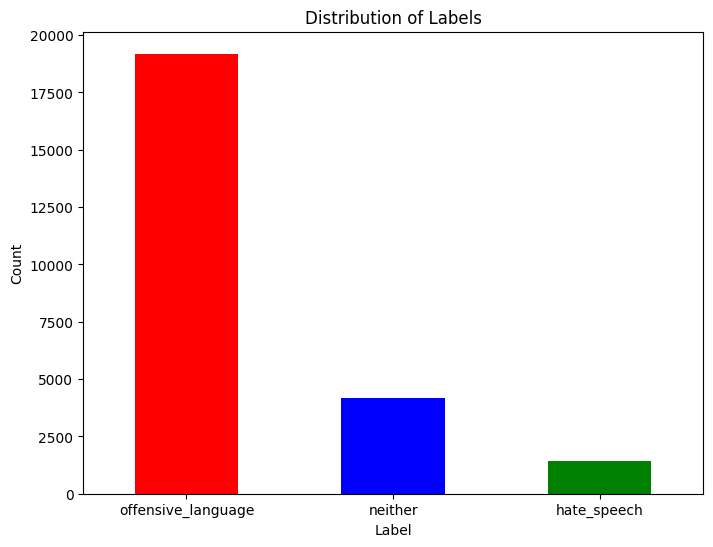

In [7]:
# Trực quan hóa phân bố nhãn:
plt.figure(figsize=(8,6))
data_cleaned['label'].value_counts().plot(kind='bar', color = ['red', 'blue', 'green'])
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 2. Tiền xử lý dữ liệu:

## 2.1. Tiền xử lý dữ liệu:

Dữ liệu tweet thường chứa nhiều thành phần gây nhiễu (URL, mention, hashtag, ký tự đặc biệt).
Bước này chuẩn hóa văn bản để mô hình tập trung vào nội dung chính.

Các thao tác được áp dụng:

- Loại bỏ URL (link)
- Loại bỏ mention (ví dụ: @username)
- Loại bỏ hashtag (ví dụ: #topic)
- Chuyển toàn bộ về chữ thường (lowercase)
- Tokenize văn bản thành các từ
- Lọc chỉ giữ token là chữ cái và loại bỏ stopwords tiếng Anh
- Ghép token trở lại thành chuỗi để đưa vào pipeline huấn luyện
- Kết quả mong đợi: cột tweet đã được làm sạch và đồng nhất định dạng trước khi đưa vào mô hình.

In [8]:
stopwords = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'#\w+', '', text)  # Remove hashtags
    text = text.lower()  # Lowercase
    tokens = word_tokenize(text)  # Tokenize
    filtered_tokens = [word for word in tokens if word.isalpha() and word not in stopwords]  # Remove stopwords and non-alphabetic tokens
    return ' '.join(filtered_tokens)
data_cleaned['tweet'] = data_cleaned['tweet'].apply(clean_text)

print('Data after cleaning:')
print(data_cleaned.head())

Data after cleaning:
                label                                              tweet
0             neither  rt woman complain cleaning house amp man alway...
1  offensive_language  rt boy dats cold tyga dwn bad cuffin dat hoe p...
2  offensive_language  rt dawg rt ever fuck bitch start cry confused ...
3  offensive_language                                rt look like tranny
4  offensive_language  rt shit hear might true might faker bitch told ya


## 2.2. Data augmentation:

- Tăng cường dữ liệu cho lớp có ít mẫu:

Data after augmentation:
label
offensive_language    19190
hate_speech            5708
neither                4163
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Labels After Augmentation')

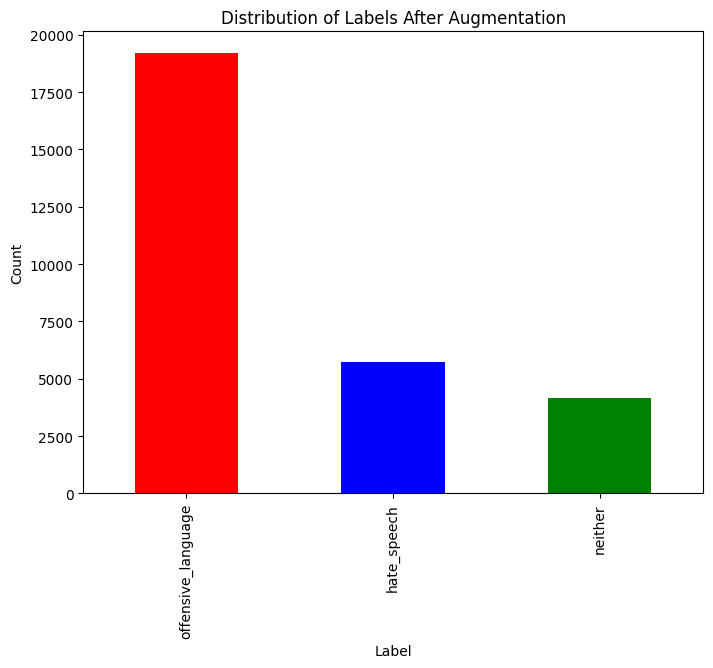

In [9]:
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

def augment_text(text, num_augments=1):
    word = text.split()
    augment_text = []

    for i in range(num_augments):
        new_words = list(word)

        if not new_words:
            continue

        random_word_index = np.random.randint(0, len(new_words))
        random_word = new_words[random_word_index]

        synonyms = get_synonyms(random_word)
        if synonyms:
            random_synonym = np.random.choice(synonyms)
            new_words[random_word_index] = random_synonym

        augment_text.append(' '.join(new_words))
    return augment_text

hate_speech_data = data_cleaned[data_cleaned['label'] == 'hate_speech'].copy()

augment_samples = []
for index, row in hate_speech_data.iterrows():
    augmented_texts  = augment_text(row['tweet'], num_augments=3)
    for aug_text in augmented_texts :
        augment_samples.append({'tweet': aug_text, 'label': 'hate_speech'})

agument_df = pd.DataFrame(augment_samples)
data_augmented = pd.concat([data_cleaned, agument_df], ignore_index=True)

print("Data after augmentation:")
print(data_augmented['label'].value_counts())
plt.figure(figsize=(8,6))
data_augmented['label'].value_counts().plot(kind='bar', color = ['red', 'blue', 'green'])
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Labels After Augmentation')

- Cân bằng dữ liệu theo số lượng mẫu giữa các lớp:

Target count for balancing: 19190

Final class distribution:
label
hate_speech           19190
neither               19190
offensive_language    19190
Name: count, dtype: int64


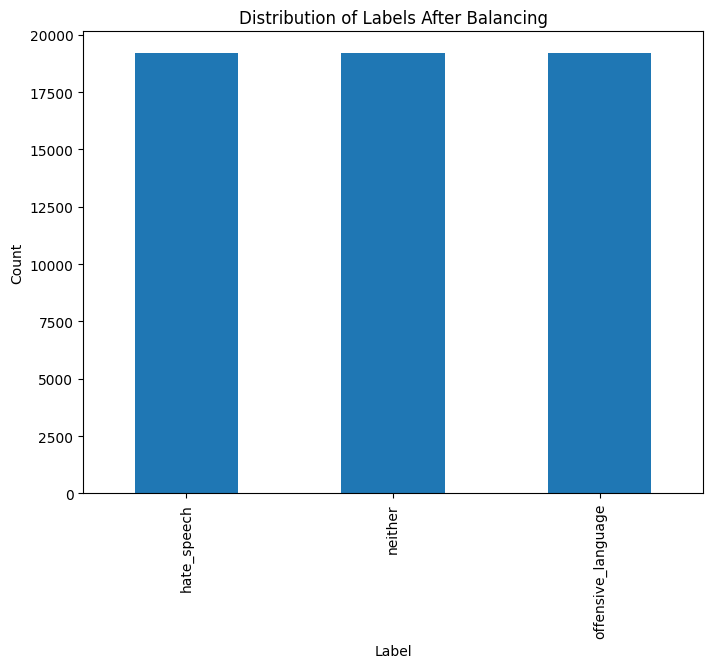

Total samples: 57570
                label                                              tweet
0         hate_speech                       rt got nigga amp got bitches
1             neither                           going free birds anyways
2         hate_speech                          fucking royals gripe work
3  offensive_language  twitter say ridin niggah really fuck pull trigger
4  offensive_language  mad cuz fucking ya enemy wins cuz letting shit...


In [10]:
# 1) Tách theo label dạng chuỗi
df_hate   = data_augmented[data_augmented['label'] == 'hate_speech'].copy()
df_off    = data_augmented[data_augmented['label'] == 'offensive_language'].copy()
df_nei    = data_augmented[data_augmented['label'] == 'neither'].copy()

# 2) Target = lớp nhiều nhất
target_count = max(len(df_hate), len(df_off), len(df_nei))
print("Target count for balancing:", target_count)

def augment_to_target(df_class, target):
    # Nếu đã >= target thì downsample về đúng target
    if len(df_class) >= target:
        return df_class.sample(n=target, replace=False, random_state=42)

    # Nếu thiếu thì oversample + augment
    need = target - len(df_class)
    seeds = df_class.sample(n=need, replace=True, random_state=42)

    augmented_rows = []
    for _, row in seeds.iterrows():
        # tạo 1 câu mới
        new_text = augment_text(row['tweet'], num_augments=1)
        new_text = new_text[0] if new_text else row['tweet']  # phòng trường hợp rỗng

        augmented_rows.append({
            'tweet': new_text,
            'label': row['label']
        })

    augmented_df = pd.DataFrame(augmented_rows)
    return pd.concat([df_class, augmented_df], ignore_index=True)

balanced_hate = augment_to_target(df_hate, target_count)
balanced_nei  = augment_to_target(df_nei, target_count)

# 3) Ghép lại dataset cân bằng (giữ offensive nguyên)
data_balanced = pd.concat([df_off, balanced_hate, balanced_nei], ignore_index=True)

# 4) Shuffle
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nFinal class distribution:")
print(data_balanced['label'].value_counts())

plt.figure(figsize=(8,6))
data_balanced['label'].value_counts().plot(kind='bar')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Labels After Balancing')
plt.show()

print("Total samples:", len(data_balanced))
print(data_balanced.head())

In [11]:
# Define integer mapping and class_names
label_to_int_map = {'hate_speech': 0, 'offensive_language': 1, 'neither': 2}
int_to_label_map = {0: 'hate_speech', 1: 'offensive_language', 2: 'neither'}
data_balanced['label_int'] = data_balanced['label'].map(label_to_int_map)
class_names = [int_to_label_map[i] for i in sorted(int_to_label_map.keys())] # Ensures order for reporting
print("Updated data_balanced with integer labels and defined class_names:", class_names)

Updated data_balanced with integer labels and defined class_names: ['hate_speech', 'offensive_language', 'neither']


# 2. Mô hình RNN cơ bản:

In [22]:
# Import các thư viện cần thiết:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

## 2.1. Tiền xử lý dữ liệu:

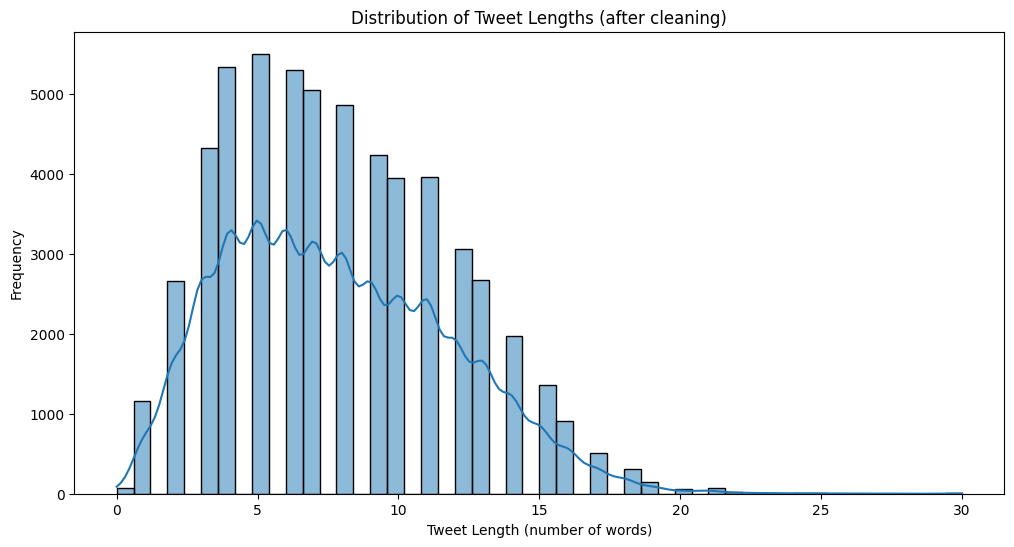

count    57570.000000
mean         7.829338
std          3.988010
min          0.000000
25%          5.000000
50%          7.000000
75%         11.000000
max         30.000000
Name: tweet_length, dtype: float64


In [12]:
# Khảo sát độ dài chuỗi sau khi clean:
data_balanced['tweet_length'] = data_balanced['tweet'].apply(lambda x: len(x.split()))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(data_balanced['tweet_length'], bins=50, kde=True)
plt.title('Distribution of Tweet Lengths (after cleaning)')
plt.xlabel('Tweet Length (number of words)')
plt.ylabel('Frequency')
plt.show()

print(data_balanced['tweet_length'].describe())

- Chia train, val, test theo tỉ lệ 8:1:1:

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    data_balanced['tweet'].values, data_balanced['label_int'].values, test_size=0.2, stratify=data_balanced['label_int'].values, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

MAX_VOCAB = min(len(tokenizer.word_index) + 1, 20000) # Cap at 20000, but use actual vocab size if smaller
# The 75th percentile of tweet length was 20, max was 87. Using 25 or 30 should capture most tweets.
# Let's update MAX_LEN to 25 to be slightly more generous than the 75th percentile, but avoid very long tails.
MAX_LEN = 25

print(f"Updated MAX_VOCAB: {MAX_VOCAB}")
print(f"Updated MAX_LEN: {MAX_LEN}")

Updated MAX_VOCAB: 20000
Updated MAX_LEN: 25


In [14]:
# Tokenization và padding tối ưu:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def encode(texts):
    return pad_sequences(
        tokenizer.texts_to_sequences(texts),
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

X_train_seq = encode(X_train)
X_val_seq   = encode(X_val)
X_test_seq  = encode(X_test)

print("Tokenization and padding updated successfully with new MAX_VOCAB and MAX_LEN.")

Tokenization and padding updated successfully with new MAX_VOCAB and MAX_LEN.


## 2.2. Load GloVe Twitter Embedding:

In [15]:
!wget http://nlp.stanford.edu/data/glove.twitter.27B.zip
!unzip glove.twitter.27B.zip

EMB_DIM = 100
embedding_index = {}

with open("glove.twitter.27B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

embedding_matrix = np.zeros((MAX_VOCAB, EMB_DIM))

for word, idx in tokenizer.word_index.items():
    if idx < MAX_VOCAB:
        vec = embedding_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

--2025-12-27 02:49:25--  http://nlp.stanford.edu/data/glove.twitter.27B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.twitter.27B.zip [following]
--2025-12-27 02:49:26--  https://nlp.stanford.edu/data/glove.twitter.27B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.twitter.27B.zip [following]
--2025-12-27 02:49:26--  https://downloads.cs.stanford.edu/nlp/data/glove.twitter.27B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1520408563 (1.4G) [ap

## 2.3. Xây dựng mô hình RNN đơn giản:

In [26]:
model_rnn = Sequential([
    Embedding(
        input_dim=MAX_VOCAB,
        output_dim=EMB_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),

    SimpleRNN(
        128,
        activation='tanh',
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.2
    ),

    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

## 2.4. Compile và train mô hình lần 1:

In [27]:
# Compile model:
optimizer = Adam(
    learning_rate=1e-3,
    clipnorm=1.0   # CỰC QUAN TRỌNG cho RNN
)

model_rnn.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [23]:
# Callbacks:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_loss',
        save_best_only=True
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir='logs',
        histogram_freq=1
    )
]

In [29]:
# Train mô hình:
history = model_rnn.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4380 - loss: 1.0611

720/720 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.4380 - loss: 1.0611 - val_accuracy: 0.4325 - val_loss: 1.0015 - learning_rate: 0.0010
Epoch 2/30
717/720 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4887 - loss: 1.0039

720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4887 - loss: 1.0039 - val_accuracy: 0.5053 - val_loss: 0.9861 - learning_rate: 0.0010
Epoch 3/30
716/720 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5149 - loss: 0.9848

720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5149 - loss: 0.9849 - val_accuracy: 0.5272 - val_loss: 0.9806 - learning_rate: 0.0010
Epoch 4/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4949 - loss: 1.0054 - val_accuracy: 0.4426 - val_loss: 1.0278 - learning_rate: 0.0010
Epoch 5/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4399 - loss: 1.0423 - val_accuracy: 0.4127 - val_loss: 1.0577 - learning_rate: 0.0010
Epoch 6/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4294 - loss: 1.0571 - val_accuracy: 0.4388 - val_loss: 1.0605 - learning_rate: 0.0010
Epoch 7/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4598 - loss: 1.0445 - val_accuracy: 0.4785 - val_loss: 1.0252 - learning_rate: 0.0010
Epoch 8/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4623 - loss: 1.0323 - val_accuracy: 0.5235 - val_loss: 0.9904 - learning_rate: 0.0010
Epoch 9/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5066 - loss: 0.9954 - val_accura

720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4710 - loss: 1.0067 - val_accuracy: 0.5576 - val_loss: 0.9197 - learning_rate: 5.0000e-04
Epoch 12/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5347 - loss: 0.9462 - val_accuracy: 0.4973 - val_loss: 0.9377 - learning_rate: 5.0000e-04
Epoch 13/30
718/720 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5349 - loss: 0.9254

...

720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6758 - loss: 0.7571 - val_accuracy: 0.7287 - val_loss: 0.6694 - learning_rate: 5.0000e-04
Epoch 25/30
718/720 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6778 - loss: 0.7518

720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6778 - loss: 0.7518 - val_accuracy: 0.7363 - val_loss: 0.6589 - learning_rate: 5.0000e-04
Epoch 26/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6842 - loss: 0.7451

720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6842 - loss: 0.7451 - val_accuracy: 0.7396 - val_loss: 0.6431 - learning_rate: 5.0000e-04
Epoch 27/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6962 - loss: 0.7352 - val_accuracy: 0.7431 - val_loss: 0.6443 - learning_rate: 5.0000e-04
Epoch 28/30
713/720 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6949 - loss: 0.7350

720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6949 - loss: 0.7349 - val_accuracy: 0.7528 - val_loss: 0.6331 - learning_rate: 5.0000e-04
Epoch 29/30
713/720 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6979 - loss: 0.7298

720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6979 - loss: 0.7298 - val_accuracy: 0.7561 - val_loss: 0.6280 - learning_rate: 5.0000e-04
Epoch 30/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7052 - loss: 0.7233 - val_accuracy: 0.7523 - val_loss: 0.6293 - learning_rate: 5.0000e-04


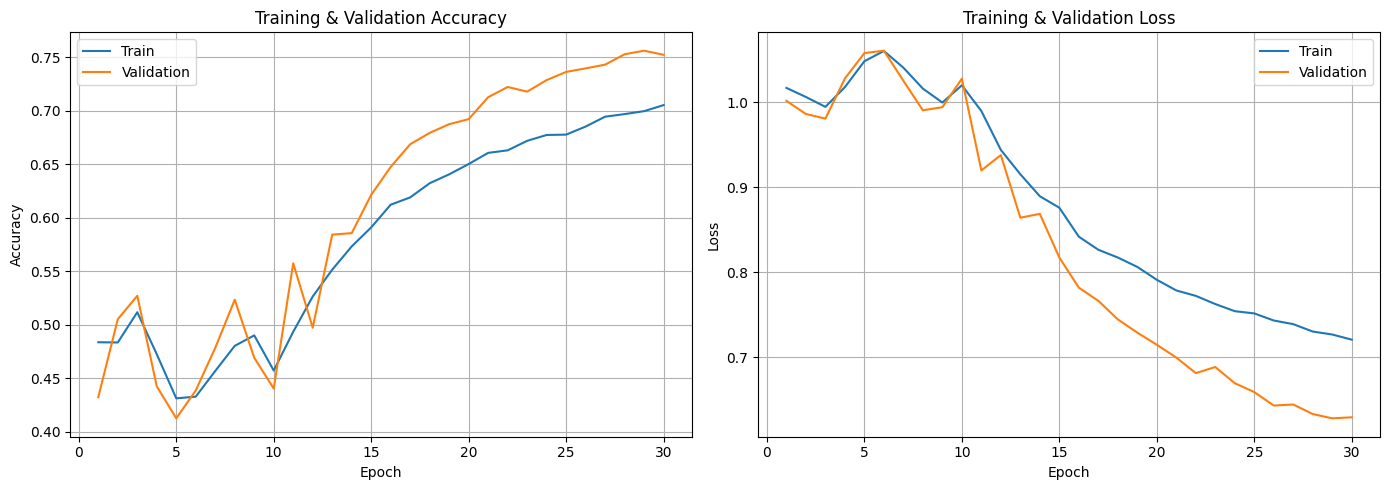

In [30]:
# In ra quá trình huấn luyện:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc)
    plt.plot(epochs, val_acc)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend(["Train", "Validation"])
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss)
    plt.plot(epochs, val_loss)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend(["Train", "Validation"])
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)


## 2.5. Mở khối embedding và train thêm lần 2:

In [31]:
# Mở embedding:
model_rnn.layers[0].trainable = True

In [32]:
model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4,   # GIẢM LR
        clipnorm=1.0
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
# Train lần 2:
history_finetune = model_rnn.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7061 - loss: 0.7161

720/720 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.7061 - loss: 0.7161 - val_accuracy: 0.7646 - val_loss: 0.6015 - learning_rate: 1.0000e-04
Epoch 2/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7202 - loss: 0.6954

720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7202 - loss: 0.6954 - val_accuracy: 0.7714 - val_loss: 0.5908 - learning_rate: 1.0000e-04
Epoch 3/20
718/720 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7304 - loss: 0.6764

720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7304 - loss: 0.6764 - val_accuracy: 0.7744 - val_loss: 0.5733 - learning_rate: 1.0000e-04
Epoch 4/20
716/720 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7334 - loss: 0.6671

720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7334 - loss: 0.6671 - val_accuracy: 0.7832 - val_loss: 0.5577 - learning_rate: 1.0000e-04
Epoch 5/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7432 - loss: 0.6514

...

720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7992 - loss: 0.5459 - val_accuracy: 0.8451 - val_loss: 0.4442 - learning_rate: 1.0000e-04
Epoch 17/20
716/720 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8046 - loss: 0.5358

720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8046 - loss: 0.5358 - val_accuracy: 0.8471 - val_loss: 0.4392 - learning_rate: 1.0000e-04
Epoch 18/20
718/720 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8074 - loss: 0.5339

720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8074 - loss: 0.5339 - val_accuracy: 0.8491 - val_loss: 0.4296 - learning_rate: 1.0000e-04
Epoch 19/20
718/720 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8109 - loss: 0.5179

720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8109 - loss: 0.5179 - val_accuracy: 0.8529 - val_loss: 0.4231 - learning_rate: 1.0000e-04
Epoch 20/20
717/720 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8216 - loss: 0.5010

720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8216 - loss: 0.5011 - val_accuracy: 0.8576 - val_loss: 0.4132 - learning_rate: 1.0000e-04


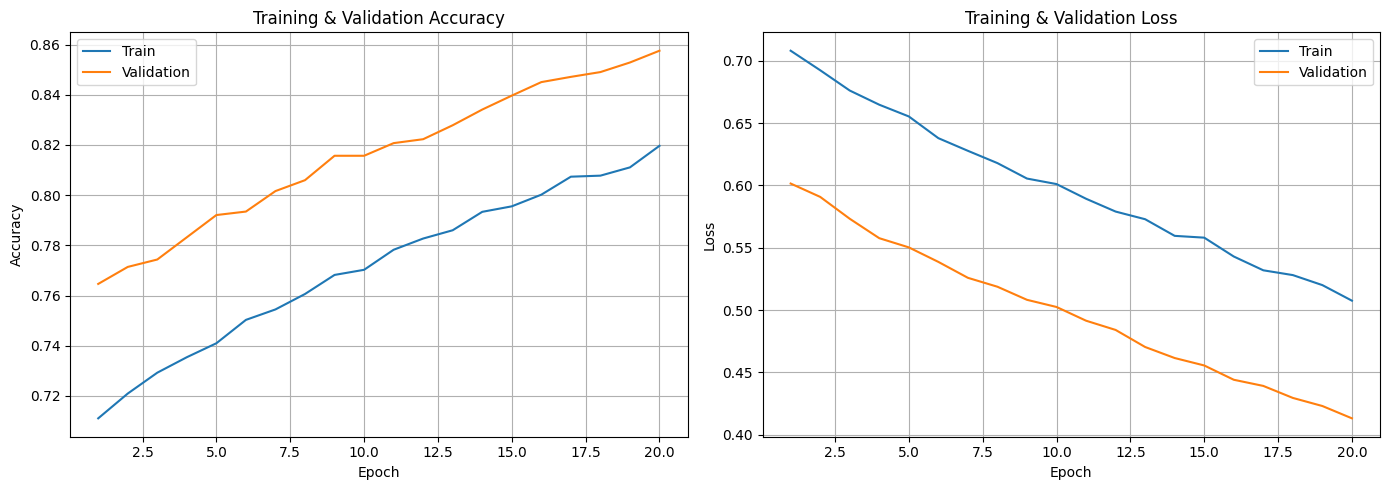

In [34]:
# In ra quá trình huấn luyện:
plot_training_history(history_finetune)

## 2.6. Đánh giá mô hình trên tập test:

In [35]:
# Test mô hình:
y_pred = np.argmax(model_rnn.predict(X_test_seq), axis=1)

print(classification_report(y_test, y_pred, target_names=[
    "Hate Speech", "Offensive", "Neither"
]))

180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

 Hate Speech       0.78      0.82      0.80      1919
   Offensive       0.85      0.82      0.84      1919
     Neither       0.91      0.91      0.91      1919

    accuracy                           0.85      5757
   macro avg       0.85      0.85      0.85      5757
weighted avg       0.85      0.85      0.85      5757



In [36]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

                    precision    recall  f1-score   support

       hate_speech     0.7841    0.8155    0.7995      1919
offensive_language     0.8542    0.8213    0.8374      1919
           neither     0.9092    0.9078    0.9085      1919

          accuracy                         0.8482      5757
         macro avg     0.8492    0.8482    0.8485      5757
      weighted avg     0.8492    0.8482    0.8485      5757



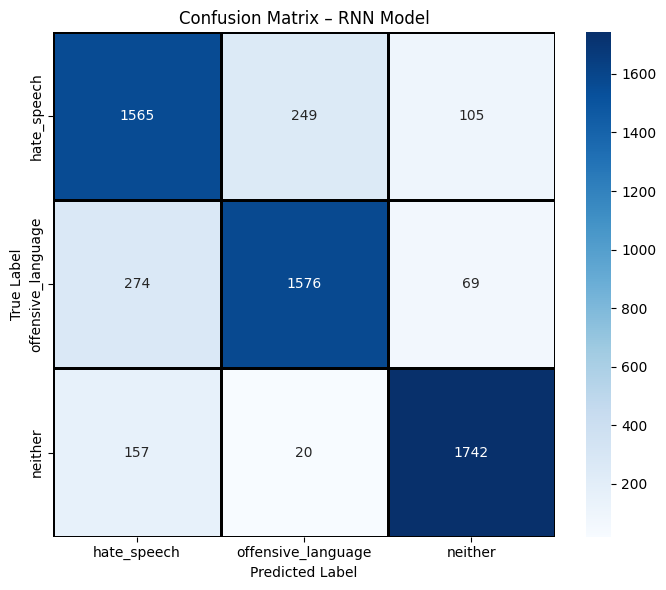

In [37]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – RNN Model")
plt.tight_layout()
plt.show()

## 2.6. Lưu mô hình về drive:

In [38]:
# Lưu mô hình về drive:
import os
SAVE_DIR = "/content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/RNN_model"
os.makedirs(SAVE_DIR, exist_ok=True)

rnn_model_path = os.path.join(SAVE_DIR, "rnn_hate_speech.keras")
model_rnn.save(rnn_model_path)
print(f"✅ RNN model saved to: {rnn_model_path}")

✅ RNN model saved to: /content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/RNN_model/rnn_hate_speech.keras


In [39]:
# Lưu tokenizer:
import pickle

tokenizer_path = os.path.join(SAVE_DIR, "tokenizer_rnn.pkl")
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

print(f"✅ Tokenizer saved to: {tokenizer_path}")

✅ Tokenizer saved to: /content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/RNN_model/tokenizer_rnn.pkl


In [40]:
# Lưu config preprocessing:
import json

config = {
    "MAX_LEN": MAX_LEN,
    "MAX_VOCAB": MAX_VOCAB,
    "LABEL_MAPPING": {
        "0": "Hate Speech",
        "1": "Offensive",
        "2": "Neither"
    }
}

config_path = os.path.join(SAVE_DIR, "config_rnn.json")

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print(f"✅ Config saved to: {config_path}")

✅ Config saved to: /content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/RNN_model/config_rnn.json


In [41]:
# Test lại model đã lưu:
from tensorflow.keras.models import load_model

loaded_rnn = load_model(rnn_model_path)

loaded_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 25, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,075,528 (15.55 MB)

 Trainable params: 2,037,763 (7.77 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,037,765 (7.77 MB)

In [42]:
sample_text = ["you are a stupid, an idiot, a cow in a small circle"]

sample_clean = [clean_text(sample_text[0])]
sample_seq = encode(sample_clean)

pred = loaded_rnn.predict(sample_seq)
pred_label = np.argmax(pred, axis=1)[0]

print("Prediction:", config["LABEL_MAPPING"][str(pred_label)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
Prediction: Hate Speech


# 3. Mô hình LSTM 1 chiều:

## 3.1. Tiền xử lý dữ liệu:

Ta giữ nguyên dữ liệu đã tiền xử lý cho RNN, áp dụng luôn cho LSTM một chiều để giữ tính công bằng.

In [43]:
# Kiểm tra lại dữ liệu đầu vào:
print(X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)
print(np.unique(y_train, return_counts=True))

(46056, 25) (5757, 25) (5757, 25)
(array([0, 1, 2]), array([15352, 15352, 15352]))


## 3.2. Xây dựng mô hình LSTM một chiều:

In [44]:
from tensorflow.keras.layers import LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout

In [45]:
model_lstm = Sequential([
    Embedding(
        input_dim=MAX_VOCAB,
        output_dim=EMB_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),

    LSTM(
        128,
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.2
    ),

    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## 3.3. Huấn luyện mô hình với cấu hình cũ:

In [46]:
# Compile model:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    clipnorm=1.0
)

model_lstm.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [47]:
# Train mô hình LSTM giai đoạn 1:
history_lstm = model_lstm.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 72s 91ms/step - accuracy: 0.6470 - loss: 0.7738 - val_accuracy: 0.8077 - val_loss: 0.4992 - learning_rate: 0.0010
Epoch 2/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 77s 90ms/step - accuracy: 0.7844 - loss: 0.5418 - val_accuracy: 0.8194 - val_loss: 0.4638 - learning_rate: 0.0010
Epoch 3/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8069 - loss: 0.4886

720/720 ━━━━━━━━━━━━━━━━━━━━ 83s 91ms/step - accuracy: 0.8069 - loss: 0.4886 - val_accuracy: 0.8513 - val_loss: 0.3911 - learning_rate: 0.0010
Epoch 4/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8266 - loss: 0.4493

720/720 ━━━━━━━━━━━━━━━━━━━━ 65s 91ms/step - accuracy: 0.8266 - loss: 0.4493 - val_accuracy: 0.8579 - val_loss: 0.3669 - learning_rate: 0.0010
Epoch 5/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8424 - loss: 0.4124

720/720 ━━━━━━━━━━━━━━━━━━━━ 65s 91ms/step - accuracy: 0.8424 - loss: 0.4124 - val_accuracy: 0.8763 - val_loss: 0.3351 - learning_rate: 0.0010
Epoch 6/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8525 - loss: 0.3877

720/720 ━━━━━━━━━━━━━━━━━━━━ 66s 92ms/step - accuracy: 0.8525 - loss: 0.3877 - val_accuracy: 0.8899 - val_loss: 0.3048 - learning_rate: 0.0010
Epoch 7/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step - accuracy: 0.8658 - loss: 0.3569 - val_accuracy: 0.8906 - val_loss: 0.3109 - learning_rate: 0.0010
Epoch 8/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8742 - loss: 0.3343

...

720/720 ━━━━━━━━━━━━━━━━━━━━ 66s 92ms/step - accuracy: 0.9326 - loss: 0.1927 - val_accuracy: 0.9392 - val_loss: 0.1800 - learning_rate: 0.0010
Epoch 23/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 66s 92ms/step - accuracy: 0.9332 - loss: 0.1893 - val_accuracy: 0.9401 - val_loss: 0.1876 - learning_rate: 0.0010
Epoch 24/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 65s 91ms/step - accuracy: 0.9347 - loss: 0.1840 - val_accuracy: 0.9409 - val_loss: 0.1845 - learning_rate: 0.0010
Epoch 25/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9381 - loss: 0.1762

720/720 ━━━━━━━━━━━━━━━━━━━━ 82s 91ms/step - accuracy: 0.9381 - loss: 0.1762 - val_accuracy: 0.9427 - val_loss: 0.1760 - learning_rate: 0.0010
Epoch 26/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9384 - loss: 0.1734

720/720 ━━━━━━━━━━━━━━━━━━━━ 66s 92ms/step - accuracy: 0.9384 - loss: 0.1734 - val_accuracy: 0.9418 - val_loss: 0.1738 - learning_rate: 0.0010
Epoch 27/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9383 - loss: 0.1747

720/720 ━━━━━━━━━━━━━━━━━━━━ 69s 95ms/step - accuracy: 0.9383 - loss: 0.1747 - val_accuracy: 0.9420 - val_loss: 0.1675 - learning_rate: 0.0010
Epoch 28/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 66s 92ms/step - accuracy: 0.9405 - loss: 0.1728 - val_accuracy: 0.9455 - val_loss: 0.1725 - learning_rate: 0.0010
Epoch 29/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 66s 92ms/step - accuracy: 0.9401 - loss: 0.1699 - val_accuracy: 0.9475 - val_loss: 0.1681 - learning_rate: 0.0010
Epoch 30/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9420 - loss: 0.1639

720/720 ━━━━━━━━━━━━━━━━━━━━ 67s 93ms/step - accuracy: 0.9420 - loss: 0.1639 - val_accuracy: 0.9500 - val_loss: 0.1603 - learning_rate: 0.0010


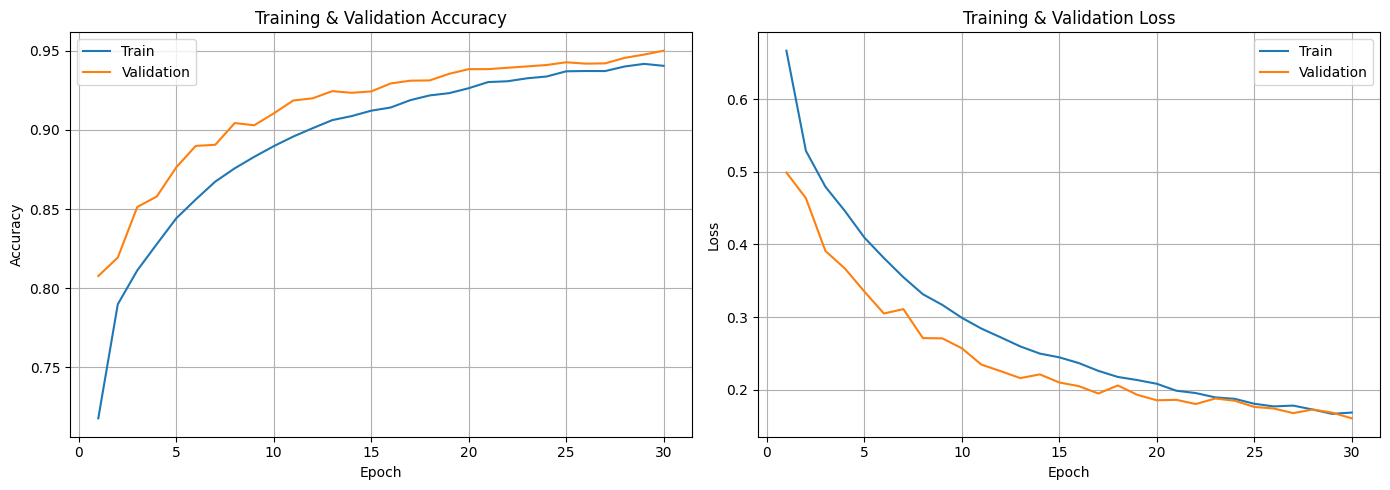

In [48]:
# In ra quá trình huấn luyện:
plot_training_history(history_lstm)

## 3.4. Mở block embedding và fine-tunning mô hình:

In [49]:
# Mở block embedding:
model_lstm.layers[0].trainable = True

In [50]:
# Fine-tune thêm 20 epoch:
model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4,
        clipnorm=1.0
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_lstm_finetune = model_lstm.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 79s 104ms/step - accuracy: 0.9440 - loss: 0.1540 - val_accuracy: 0.9498 - val_loss: 0.1640 - learning_rate: 1.0000e-04
Epoch 2/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 81s 102ms/step - accuracy: 0.9511 - loss: 0.1398 - val_accuracy: 0.9500 - val_loss: 0.1628 - learning_rate: 1.0000e-04
Epoch 3/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 74s 103ms/step - accuracy: 0.9524 - loss: 0.1349 - val_accuracy: 0.9501 - val_loss: 0.1612 - learning_rate: 1.0000e-04
Epoch 4/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9534 - loss: 0.1329

720/720 ━━━━━━━━━━━━━━━━━━━━ 76s 106ms/step - accuracy: 0.9534 - loss: 0.1329 - val_accuracy: 0.9515 - val_loss: 0.1584 - learning_rate: 1.0000e-04
Epoch 5/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9553 - loss: 0.1293

720/720 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.9553 - loss: 0.1293 - val_accuracy: 0.9529 - val_loss: 0.1556 - learning_rate: 1.0000e-04
Epoch 6/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9589 - loss: 0.1206

720/720 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - accuracy: 0.9588 - loss: 0.1206 - val_accuracy: 0.9531 - val_loss: 0.1517 - learning_rate: 1.0000e-04
Epoch 7/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.9594 - loss: 0.1177 - val_accuracy: 0.9541 - val_loss: 0.1530 - learning_rate: 1.0000e-04
Epoch 8/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.9619 - loss: 0.1132 - val_accuracy: 0.9536 - val_loss: 0.1535 - learning_rate: 1.0000e-04
Epoch 9/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 84s 104ms/step - accuracy: 0.9608 - loss: 0.1105 - val_accuracy: 0.9545 - val_loss: 0.1526 - learning_rate: 1.0000e-04
Epoch 10/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 82s 104ms/step - accuracy: 0.9608 - loss: 0.1103 - val_accuracy: 0.9538 - val_loss: 0.1580 - learning_rate: 1.0000e-04
Epoch 11/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - accuracy: 0.9631 - loss: 0.1075 - val_accuracy: 0.9547 - val_loss: 0.1530 - learning_rate: 1.0000e-04
Epoch 12/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step -

720/720 ━━━━━━━━━━━━━━━━━━━━ 73s 102ms/step - accuracy: 0.9646 - loss: 0.1015 - val_accuracy: 0.9566 - val_loss: 0.1498 - learning_rate: 5.0000e-05
Epoch 13/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - accuracy: 0.9637 - loss: 0.1054 - val_accuracy: 0.9564 - val_loss: 0.1540 - learning_rate: 5.0000e-05
Epoch 14/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.9655 - loss: 0.0975 - val_accuracy: 0.9567 - val_loss: 0.1500 - learning_rate: 5.0000e-05
Epoch 15/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - accuracy: 0.9668 - loss: 0.1007 - val_accuracy: 0.9569 - val_loss: 0.1520 - learning_rate: 5.0000e-05
Epoch 16/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.9665 - loss: 0.0981 - val_accuracy: 0.9576 - val_loss: 0.1510 - learning_rate: 5.0000e-05
Epoch 17/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 76s 105ms/step - accuracy: 0.9674 - loss: 0.0942 - val_accuracy: 0.9573 - val_loss: 0.1500 - learning_rate: 5.0000e-05
Epoch 18/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/st

720/720 ━━━━━━━━━━━━━━━━━━━━ 76s 105ms/step - accuracy: 0.9672 - loss: 0.0925 - val_accuracy: 0.9576 - val_loss: 0.1495 - learning_rate: 2.5000e-05
Epoch 19/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.9683 - loss: 0.0923 - val_accuracy: 0.9574 - val_loss: 0.1503 - learning_rate: 2.5000e-05
Epoch 20/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9676 - loss: 0.0906

720/720 ━━━━━━━━━━━━━━━━━━━━ 75s 105ms/step - accuracy: 0.9676 - loss: 0.0906 - val_accuracy: 0.9580 - val_loss: 0.1494 - learning_rate: 2.5000e-05


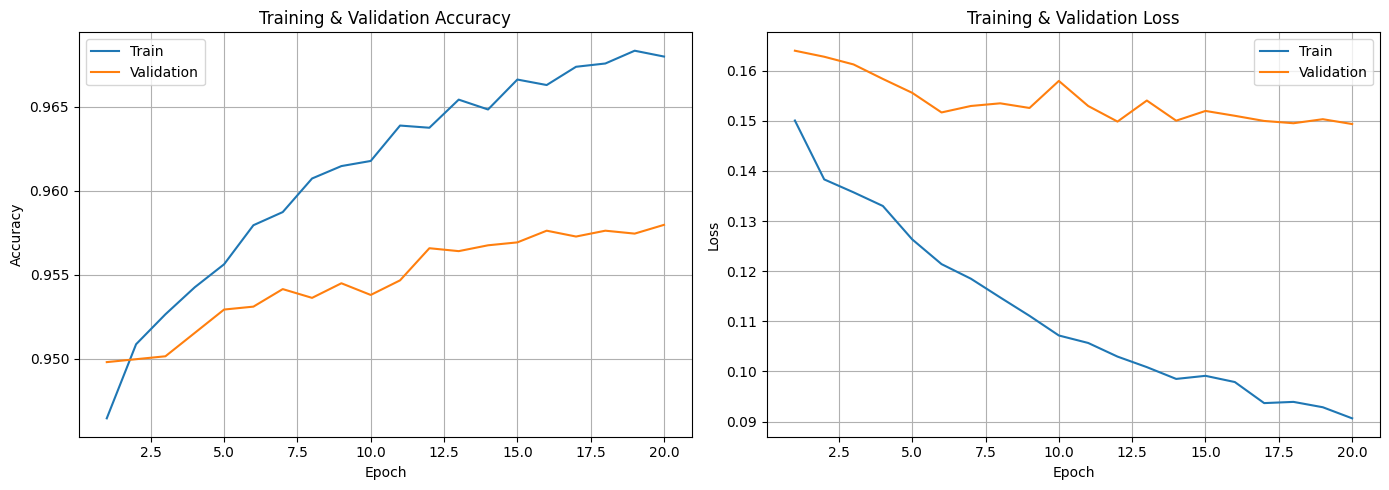

In [51]:
# In ra quá trình huấn luyện:
plot_training_history(history_lstm_finetune)

## 3.5. Đánh giá mô hình trên tập test:

In [52]:
# Đánh giá model trên tập test:
y_pred_lstm = np.argmax(model_lstm.predict(X_test_seq), axis=1)

print(classification_report(y_test, y_pred_lstm, target_names=[
    "Hate Speech", "Offensive", "Neither"
]))

180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step
              precision    recall  f1-score   support

 Hate Speech       0.94      0.98      0.96      1919
   Offensive       0.98      0.91      0.95      1919
     Neither       0.96      0.98      0.97      1919

    accuracy                           0.96      5757
   macro avg       0.96      0.96      0.96      5757
weighted avg       0.96      0.96      0.96      5757



In [53]:
report = classification_report(
    y_test,
    y_pred_lstm,
    target_names=class_names,
    digits=4
)

print(report)

                    precision    recall  f1-score   support

       hate_speech     0.9444    0.9833    0.9635      1919
offensive_language     0.9794    0.9145    0.9458      1919
           neither     0.9609    0.9849    0.9727      1919

          accuracy                         0.9609      5757
         macro avg     0.9616    0.9609    0.9607      5757
      weighted avg     0.9616    0.9609    0.9607      5757



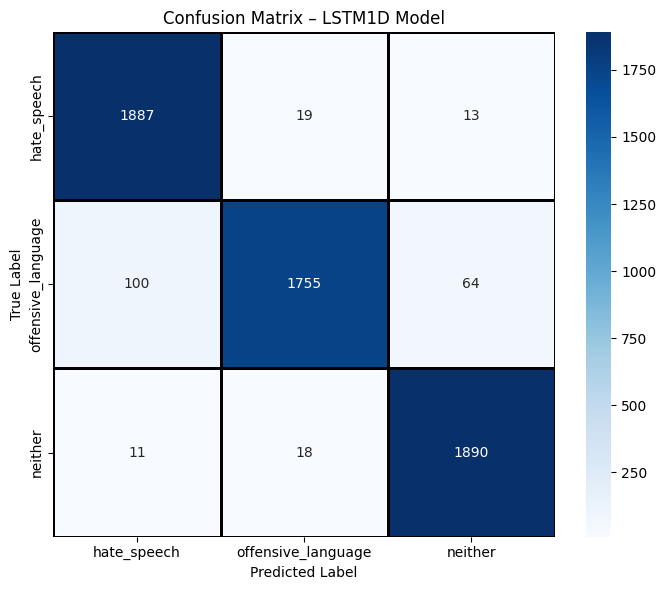

In [54]:
cm = confusion_matrix(y_test, y_pred_lstm)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – LSTM1D Model")
plt.tight_layout()
plt.show()

## 3.6. Lưu mô hình về drive:

In [55]:
# Lưu mô hình về drive:
import os
SAVE_DIR = "/content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/LSTM1D_model"
os.makedirs(SAVE_DIR, exist_ok=True)

lstm_model_path = os.path.join(SAVE_DIR, "lstm1d_hate_speech.keras")
model_lstm.save(lstm_model_path)
print(f"LSTM model saved to: {lstm_model_path}")

LSTM model saved to: /content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/LSTM1D_model/lstm1d_hate_speech.keras


In [56]:
# Lưu tokenizer:
import pickle

tokenizer_path = os.path.join(SAVE_DIR, "tokenizer_lstm1d.pkl")
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

print(f"✅ Tokenizer saved to: {tokenizer_path}")

✅ Tokenizer saved to: /content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/LSTM1D_model/tokenizer_lstm1d.pkl


In [57]:
# Lưu config preprocessing:
import json

config = {
    "MAX_LEN": MAX_LEN,
    "MAX_VOCAB": MAX_VOCAB,
    "LABEL_MAPPING": {
        "0": "Hate Speech",
        "1": "Offensive",
        "2": "Neither"
    }
}

config_path = os.path.join(SAVE_DIR, "config_lstm1d.json")

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print(f"✅ Config saved to: {config_path}")

✅ Config saved to: /content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/LSTM1D_model/config_lstm1d.json


In [58]:
# Test lại model đã lưu:
from tensorflow.keras.models import load_model

loaded_lstm = load_model(lstm_model_path)

loaded_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 25, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,251,400 (16.22 MB)

 Trainable params: 2,125,699 (8.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,125,701 (8.11 MB)

In [59]:
sample_text = ["you are a stupid, an idiot, a cow in a small circle"]

sample_clean = [clean_text(sample_text[0])]
sample_seq = encode(sample_clean)

pred = loaded_lstm.predict(sample_seq)
pred_label = np.argmax(pred, axis=1)[0]

print("Prediction:", config["LABEL_MAPPING"][str(pred_label)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
Prediction: Hate Speech


# 4. Mô hình Bi-directional LSTM (LSTM hai chiều):

## 4.1. Tiền xử lý dữ liệu:

- Ta giữ nguyên tiền xử lý như trước.

In [16]:
# Kiểm tra lại dữ liệu đầu vào:
print(X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)
print(np.unique(y_train, return_counts=True))

(46056, 25) (5757, 25) (5757, 25)
(array([0, 1, 2]), array([15352, 15352, 15352]))


## 4.2. Xây dựng mô hình Bidirectional LSTM:

In [17]:
from tensorflow.keras.layers import Bidirectional, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout

In [18]:
model_bilstm = Sequential([
    Embedding(
        input_dim=MAX_VOCAB,
        output_dim=EMB_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=False,
            dropout=0.3,
            recurrent_dropout=0.2
        )
    ),

    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## 4.3. Huấn luyện model đợt 1:

In [19]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    clipnorm=1.0
)

model_bilstm.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_bilstm.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [24]:
history_bilstm = model_bilstm.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6768 - loss: 0.7199

720/720 ━━━━━━━━━━━━━━━━━━━━ 118s 152ms/step - accuracy: 0.6769 - loss: 0.7198 - val_accuracy: 0.8204 - val_loss: 0.4568 - learning_rate: 0.0010
Epoch 2/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8015 - loss: 0.4943

720/720 ━━━━━━━━━━━━━━━━━━━━ 137s 146ms/step - accuracy: 0.8015 - loss: 0.4943 - val_accuracy: 0.8624 - val_loss: 0.3753 - learning_rate: 0.0010
Epoch 3/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8358 - loss: 0.4200

720/720 ━━━━━━━━━━━━━━━━━━━━ 105s 146ms/step - accuracy: 0.8358 - loss: 0.4200 - val_accuracy: 0.8815 - val_loss: 0.3310 - learning_rate: 0.0010
Epoch 4/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8609 - loss: 0.3679

720/720 ━━━━━━━━━━━━━━━━━━━━ 147s 153ms/step - accuracy: 0.8609 - loss: 0.3679 - val_accuracy: 0.9027 - val_loss: 0.2858 - learning_rate: 0.0010
Epoch 5/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8805 - loss: 0.3204

...

720/720 ━━━━━━━━━━━━━━━━━━━━ 145s 148ms/step - accuracy: 0.9328 - loss: 0.1848 - val_accuracy: 0.9385 - val_loss: 0.1920 - learning_rate: 0.0010
Epoch 12/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 139s 143ms/step - accuracy: 0.9378 - loss: 0.1727 - val_accuracy: 0.9345 - val_loss: 0.1951 - learning_rate: 0.0010
Epoch 13/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9403 - loss: 0.1656

720/720 ━━━━━━━━━━━━━━━━━━━━ 150s 154ms/step - accuracy: 0.9403 - loss: 0.1656 - val_accuracy: 0.9420 - val_loss: 0.1843 - learning_rate: 0.0010
Epoch 14/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 106s 147ms/step - accuracy: 0.9423 - loss: 0.1583 - val_accuracy: 0.9361 - val_loss: 0.1956 - learning_rate: 0.0010
Epoch 15/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9475 - loss: 0.1460

720/720 ━━━━━━━━━━━━━━━━━━━━ 140s 144ms/step - accuracy: 0.9475 - loss: 0.1460 - val_accuracy: 0.9458 - val_loss: 0.1748 - learning_rate: 0.0010
Epoch 16/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 142s 145ms/step - accuracy: 0.9499 - loss: 0.1362 - val_accuracy: 0.9434 - val_loss: 0.1856 - learning_rate: 0.0010
Epoch 17/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 143s 146ms/step - accuracy: 0.9518 - loss: 0.1327 - val_accuracy: 0.9453 - val_loss: 0.1833 - learning_rate: 0.0010
Epoch 18/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9539 - loss: 0.1282

720/720 ━━━━━━━━━━━━━━━━━━━━ 110s 153ms/step - accuracy: 0.9539 - loss: 0.1282 - val_accuracy: 0.9462 - val_loss: 0.1714 - learning_rate: 0.0010
Epoch 19/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 138s 147ms/step - accuracy: 0.9551 - loss: 0.1230 - val_accuracy: 0.9429 - val_loss: 0.1856 - learning_rate: 0.0010
Epoch 20/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 107s 148ms/step - accuracy: 0.9562 - loss: 0.1180 - val_accuracy: 0.9463 - val_loss: 0.1863 - learning_rate: 0.0010
Epoch 21/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 105s 146ms/step - accuracy: 0.9564 - loss: 0.1182 - val_accuracy: 0.9500 - val_loss: 0.1725 - learning_rate: 0.0010
Epoch 22/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 142s 146ms/step - accuracy: 0.9584 - loss: 0.1174 - val_accuracy: 0.9449 - val_loss: 0.1949 - learning_rate: 0.0010
Epoch 23/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9613 - loss: 0.1069

720/720 ━━━━━━━━━━━━━━━━━━━━ 114s 158ms/step - accuracy: 0.9613 - loss: 0.1069 - val_accuracy: 0.9534 - val_loss: 0.1682 - learning_rate: 0.0010
Epoch 24/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 106s 147ms/step - accuracy: 0.9637 - loss: 0.1009 - val_accuracy: 0.9463 - val_loss: 0.1899 - learning_rate: 0.0010
Epoch 25/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 105s 146ms/step - accuracy: 0.9653 - loss: 0.0980 - val_accuracy: 0.9529 - val_loss: 0.1712 - learning_rate: 0.0010
Epoch 26/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 104s 144ms/step - accuracy: 0.9638 - loss: 0.0964 - val_accuracy: 0.9503 - val_loss: 0.1785 - learning_rate: 0.0010
Epoch 27/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 105s 146ms/step - accuracy: 0.9664 - loss: 0.0929 - val_accuracy: 0.9531 - val_loss: 0.1760 - learning_rate: 0.0010
Epoch 28/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 148s 155ms/step - accuracy: 0.9688 - loss: 0.0897 - val_accuracy: 0.9541 - val_loss: 0.1718 - learning_rate: 0.0010
Epoch 29/30
720/720 ━━━━━━━━━━━━━━━━━━━━ 106s 147ms/step - accuracy: 0

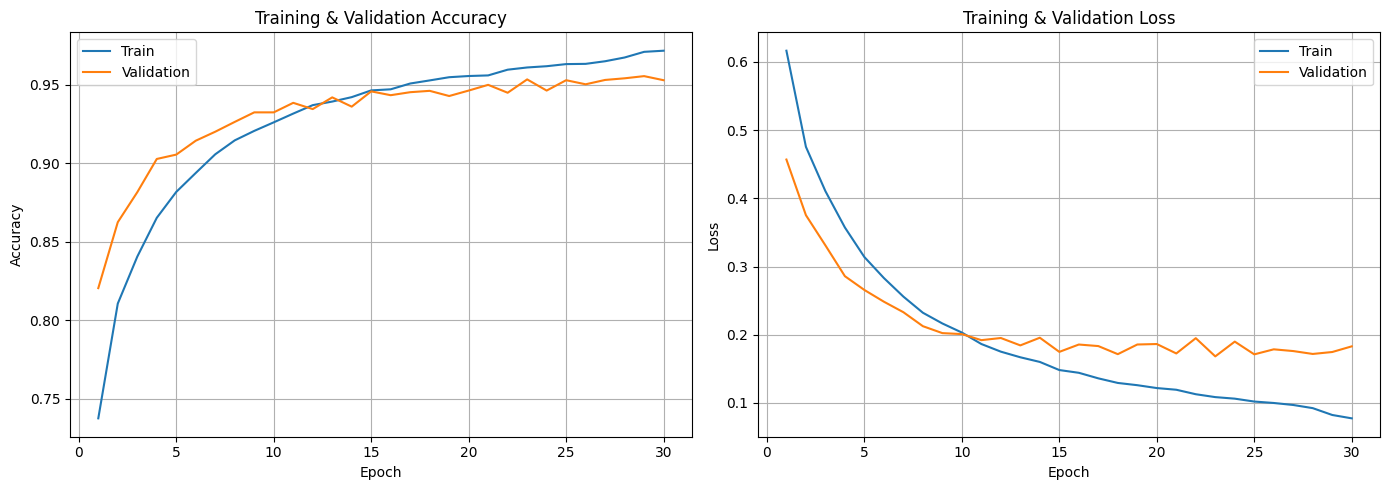

In [25]:
# In ra quá trình huấn luyện:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc)
    plt.plot(epochs, val_acc)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend(["Train", "Validation"])
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss)
    plt.plot(epochs, val_loss)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend(["Train", "Validation"])
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history_bilstm)

## 4.4. Mở block embedding và fine-tune lần 2:

In [26]:
# Mở block embedding:
model_bilstm.layers[0].trainable = True

In [27]:
model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4,
        clipnorm=1.0
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
# Train thêm 20 epoch:
history_bilstm_finetune = model_bilstm.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 145s 189ms/step - accuracy: 0.9670 - loss: 0.0935 - val_accuracy: 0.9528 - val_loss: 0.1709 - learning_rate: 1.0000e-04
Epoch 2/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 144s 192ms/step - accuracy: 0.9693 - loss: 0.0877 - val_accuracy: 0.9534 - val_loss: 0.1705 - learning_rate: 1.0000e-04
Epoch 3/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 131s 181ms/step - accuracy: 0.9721 - loss: 0.0786 - val_accuracy: 0.9545 - val_loss: 0.1748 - learning_rate: 1.0000e-04
Epoch 4/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 144s 184ms/step - accuracy: 0.9729 - loss: 0.0737 - val_accuracy: 0.9555 - val_loss: 0.1712 - learning_rate: 1.0000e-04
Epoch 5/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 129s 179ms/step - accuracy: 0.9749 - loss: 0.0728 - val_accuracy: 0.9566 - val_loss: 0.1736 - learning_rate: 1.0000e-04
Epoch 6/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 128s 178ms/step - accuracy: 0.9750 - loss: 0.0690 - val_accuracy: 0.9566 - val_loss: 0.1758 - learning_rate: 1.0000e-04
Epoch 7/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 

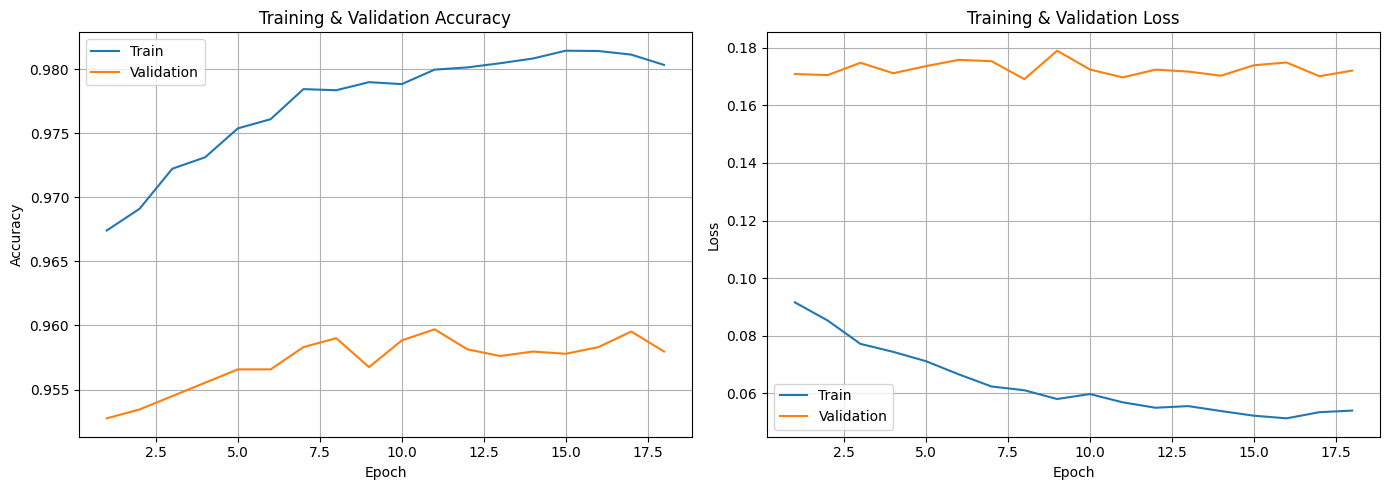

In [29]:
# In ra quá trình huấn luyện:
plot_training_history(history_bilstm_finetune)

## 4.5. Đánh giá model trên tập test:

In [30]:
# Đánh giá model trên tập test:
y_pred_bilstm = np.argmax(model_bilstm.predict(X_test_seq), axis=1)

print(classification_report(y_test, y_pred_bilstm, target_names=[
    "Hate Speech", "Offensive", "Neither"
]))

180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step
              precision    recall  f1-score   support

 Hate Speech       0.94      0.98      0.96      1919
   Offensive       0.98      0.91      0.94      1919
     Neither       0.96      0.99      0.98      1919

    accuracy                           0.96      5757
   macro avg       0.96      0.96      0.96      5757
weighted avg       0.96      0.96      0.96      5757



In [31]:
report = classification_report(
    y_test,
    y_pred_bilstm,
    target_names=class_names,
    digits=4
)

print(report)

                    precision    recall  f1-score   support

       hate_speech     0.9438    0.9807    0.9619      1919
offensive_language     0.9787    0.9119    0.9442      1919
           neither     0.9615    0.9896    0.9753      1919

          accuracy                         0.9607      5757
         macro avg     0.9614    0.9607    0.9605      5757
      weighted avg     0.9614    0.9607    0.9605      5757



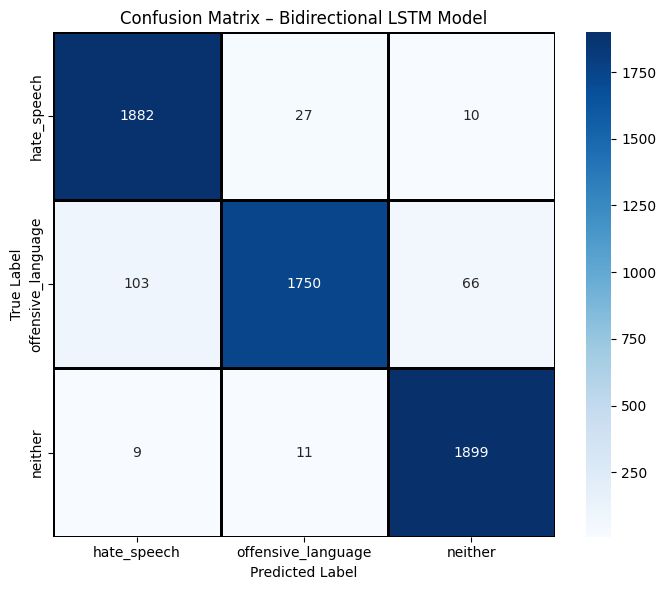

In [32]:
cm = confusion_matrix(y_test, y_pred_bilstm)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Bidirectional LSTM Model")
plt.tight_layout()
plt.show()

## 4.6. Lưu model về drive:

In [33]:
# Lưu mô hình về drive:
import os
SAVE_DIR = "/content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/BiLSTM_model"
os.makedirs(SAVE_DIR, exist_ok=True)

bilstm_model_path = os.path.join(SAVE_DIR, "bilstm_hate_speech.keras")
model_bilstm.save(bilstm_model_path)
print(f"Bi-LSTM model saved to: {bilstm_model_path}")

Bi-LSTM model saved to: /content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/BiLSTM_model/bilstm_hate_speech.keras


In [34]:
# Lưu tokenizer:
import pickle

tokenizer_path = os.path.join(SAVE_DIR, "tokenizer_bilstm.pkl")
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

print(f"✅ Tokenizer saved to: {tokenizer_path}")

✅ Tokenizer saved to: /content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/BiLSTM_model/tokenizer_bilstm.pkl


In [35]:
# Lưu config preprocessing:
import json

config = {
    "MAX_LEN": MAX_LEN,
    "MAX_VOCAB": MAX_VOCAB,
    "LABEL_MAPPING": {
        "0": "Hate Speech",
        "1": "Offensive",
        "2": "Neither"
    }
}

config_path = os.path.join(SAVE_DIR, "config_bilstm.json")

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print(f"✅ Config saved to: {config_path}")

✅ Config saved to: /content/drive/MyDrive/NLP/Final_Project/CNTDW/hate_speech_models/BiLSTM_model/config_bilstm.json


In [36]:
# Test lại model đã lưu:
from tensorflow.keras.models import load_model

loaded_bilstm = load_model(bilstm_model_path)

loaded_bilstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 25, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,753,419 (25.76 MB)

 Trainable params: 2,251,139 (8.59 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,502,280 (17.17 MB)

In [37]:
sample_text = ["you are a stupid, an idiot, a cow in a small circle"]

sample_clean = [clean_text(sample_text[0])]
sample_seq = encode(sample_clean)

pred = loaded_bilstm.predict(sample_seq)
pred_label = np.argmax(pred, axis=1)[0]

print("Prediction:", config["LABEL_MAPPING"][str(pred_label)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step
Prediction: Hate Speech
